# 《生物医学图像处理》实验2 实验报告

姓名：林亨   学号：3230103696   专业：生物医学工程

声明：本实验实验代码由gemini 3.1 pro辅助编写完成，本人已充分理解实验代码内容。

# Project 1: Spatial Transform


## 实验要求

基本任务：使用提供的lab2_MRI.npy数据，设计并实现以下实验。
- 正向-反向旋转： 将图像旋转 $\pi/5$，然后再将其旋转回 $-\theta$ 以恢复到原始位置 。
- 插值方法对比： 使用最近邻插值 (Nearest Neighbor) 和双线性插值 (Bilinear interpolation) 来执行上述旋转操作 。
- 结果分析：使用箭头标出并突出显示（如果需要可以放大）两种插值方法之间存在显著差异的区域。展示并量化原始图像与恢复后图像之间的差异。
- 附加题 (Bonus)： 比较 1 次旋转循环（$\theta \to -\theta$）与 5 次连续旋转循环之间的信息损失情况。
- 技术要求：必须使用矩阵运算 (matrix operator) 实现 。

完成这个项目需要运用矩阵运算来实现图像的仿射变换，而不是简单地调用现成的旋转函数（如 scipy.ndimage.rotate）。
核心思路是反向映射：对于目标图像上的每一个像素点，通过逆旋转矩阵计算出它在原图像中的对应坐标，然后根据该坐标进行最近邻或双线性插值。

## 实验原理 
假设图像中心为原点，为了将图像旋转角度 $\theta$，目标图像坐标 $\begin{bmatrix} x' \\ y' \end{bmatrix}$ 与原图像坐标 $\begin{bmatrix} x \\ y \end{bmatrix}$ 之间的反向映射关系由逆旋转矩阵决定：$$\begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} \cos\theta & \sin\theta \\ -\sin\theta & \cos\theta \end{bmatrix} \begin{bmatrix} x' \\ y' \end{bmatrix}$$我们将利用 Numpy 的网格（meshgrid）生成所有坐标点，并用矩阵乘法一次性完成所有像素坐标的变换。

在利用逆旋转矩阵进行反向映射的过程中，计算出的原图像坐标通常包含小数，因此必须通过插值算法来确定该小数坐标对应的像素值。

- 最近邻插值 (Nearest Neighbor Interpolation)：这是最简单直观的一种插值方法。它直接寻找空间距离上离计算出的小数坐标最近的实际原始像素点，并将其灰度值赋给目标像素。这种方法计算速度极快，且不会产生原始图像中不存在的新灰度值，但其缺点是空间精度较低，在图像边缘会造成明显的锯齿状伪影。

- 双线性插值 (Bilinear Interpolation)：该方法考虑了计算出的小数坐标周围的4个相邻像素点。通过在水平和垂直两个方向上分别进行线性插值，计算出这4个点的空间加权平均值作为目标像素的灰度值。相比最近邻插值，双线性插值得到的图像结构过渡更加平滑，能有效减轻锯齿现象；其缺点是计算量相对较大，且具有一定的低通滤波效应，可能会使图像的高频细节（边缘）略微变模糊。

量化指标对比 (1次旋转循环):
最近邻插值 -> MSE: 166.7169
双线性插值 -> MSE: 60.3928
已自动锁定最大差异区域: 左上角坐标 (64, 128), 窗口大小 76x76


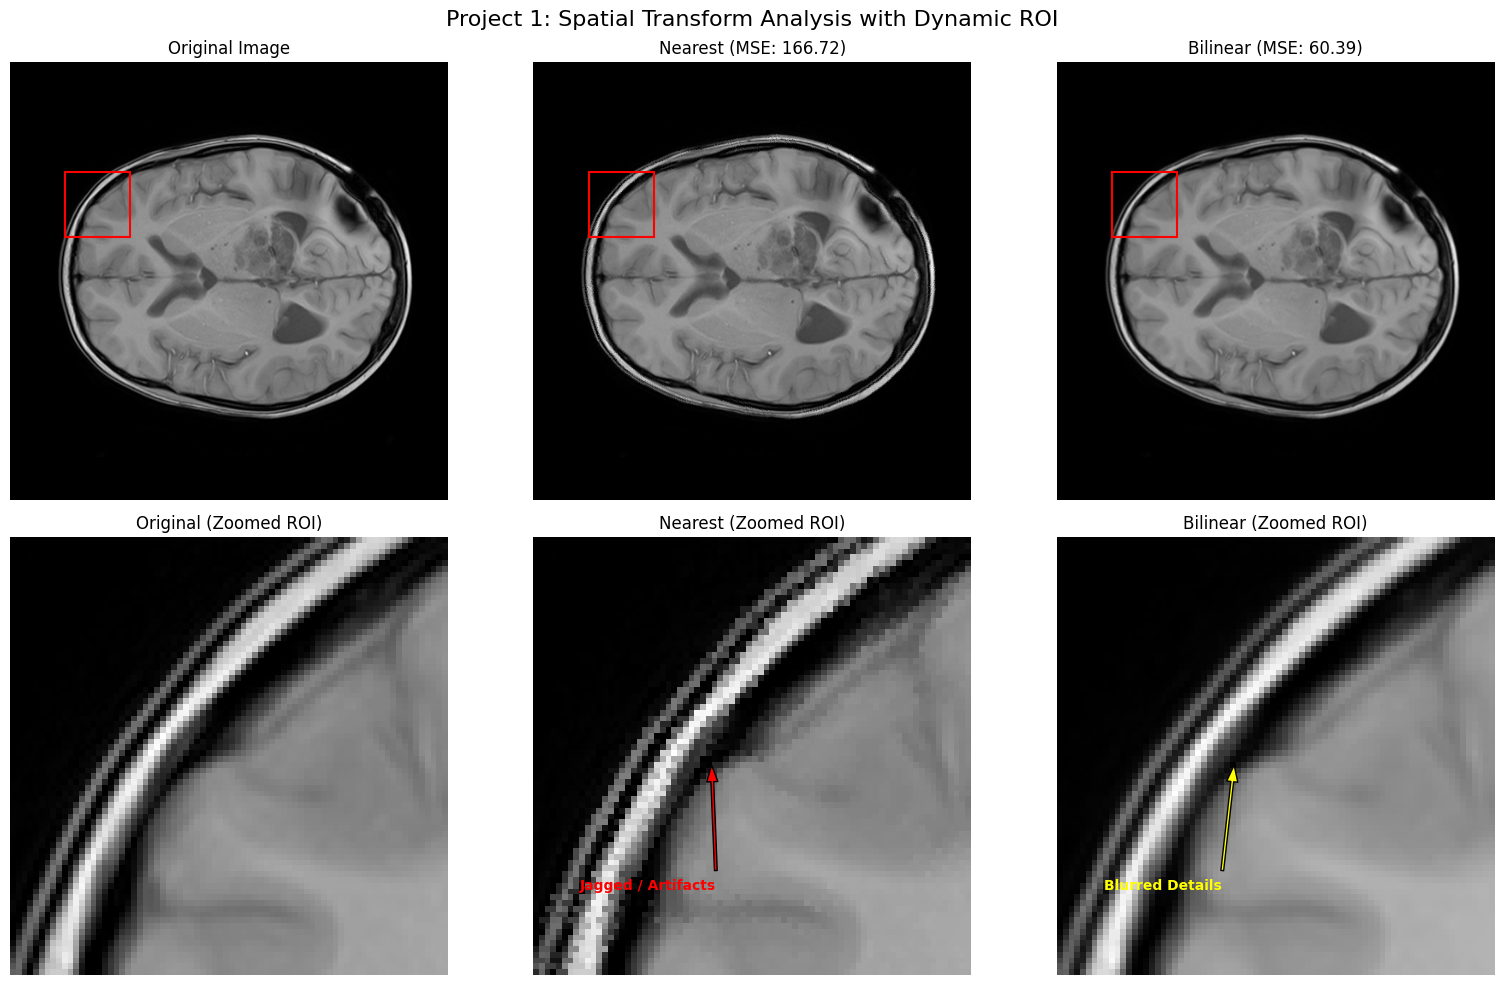

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ==========================================
# 1. 核心矩阵运算函数 (Matrix Operator)
# ==========================================
def matrix_rotate(img, theta, method='nearest'):
    """
    使用矩阵运算实现图像的反向映射旋转
    """
    H, W = img.shape
    cx, cy = (W - 1) / 2.0, (H - 1) / 2.0 

    # 生成目标图像的所有坐标点网格
    x = np.arange(W)
    y = np.arange(H)
    xx, yy = np.meshgrid(x, y)

    # 平移坐标系，使中心为原点
    xx_c = xx - cx
    yy_c = yy - cy

    # 展平坐标并堆叠成 2xN 矩阵
    coords = np.vstack((xx_c.flatten(), yy_c.flatten()))

    # 构建反向映射的旋转矩阵 R(-theta)
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)
    R_inv = np.array([[cos_t, sin_t],
                      [-sin_t, cos_t]])

    # 矩阵乘法计算原图坐标
    src_coords = R_inv @ coords

    # 平移回原坐标系并重塑为图像形状
    src_x = (src_coords[0, :] + cx).reshape(H, W)
    src_y = (src_coords[1, :] + cy).reshape(H, W)

    out_img = np.zeros_like(img, dtype=np.float32)

    # 标记在原图范围内的有效坐标点 (防止越界)
    valid = (src_x >= 0) & (src_x <= W - 1) & (src_y >= 0) & (src_y <= H - 1)

    if method == 'nearest':
        # 最近邻插值
        src_x_round = np.round(src_x).astype(int)
        src_y_round = np.round(src_y).astype(int)
        out_img[valid] = img[src_y_round[valid], src_x_round[valid]]

    elif method == 'bilinear':
        # 双线性插值
        x0 = np.floor(src_x).astype(int)
        x1 = x0 + 1
        y0 = np.floor(src_y).astype(int)
        y1 = y0 + 1

        x0 = np.clip(x0, 0, W - 1)
        x1 = np.clip(x1, 0, W - 1)
        y0 = np.clip(y0, 0, H - 1)
        y1 = np.clip(y1, 0, H - 1)

        wa = (x1 - src_x) * (y1 - src_y)
        wb = (src_x - x0) * (y1 - src_y)
        wc = (x1 - src_x) * (src_y - y0)
        wd = (src_x - x0) * (src_y - y0)

        pixel_vals = (img[y0, x0] * wa + img[y0, x1] * wb + 
                      img[y1, x0] * wc + img[y1, x1] * wd)
        
        out_img[valid] = pixel_vals[valid]

    return out_img

# ==========================================
# 2. 辅助分析函数 (误差计算 & 动态ROI寻找)
# ==========================================
def calculate_mse(original, recovered):
    """精确计算 MSE (去除黑色背景干扰)"""
    mask = original > 1e-5
    return np.mean((original[mask] - recovered[mask])**2)

def find_max_diff_roi(img1, img2, roi_size):
    """通过滑动窗口（均值滤波）自动寻找两张图像差异最大的区域"""
    diff = np.abs(img1 - img2)
    local_mean_diff = cv2.blur(diff, (roi_size, roi_size))
    _, _, _, max_loc = cv2.minMaxLoc(local_mean_diff)
    
    x_center, y_center = max_loc
    x1 = max(0, x_center - roi_size // 2)
    y1 = max(0, y_center - roi_size // 2)
    
    x1 = min(x1, img1.shape[1] - roi_size)
    y1 = min(y1, img1.shape[0] - roi_size)
    return x1, y1

# ==========================================
# 3. 实验主体执行：加载数据与变换
# ==========================================
file_path = os.path.join('lab2_data', 'lab2_MRI.npy')
img = np.load(file_path)
theta = np.pi / 5

# 执行 1 次旋转循环
img_fwd_nn = matrix_rotate(img, theta, method='nearest')
img_rec_nn = matrix_rotate(img_fwd_nn, -theta, method='nearest')

img_fwd_bi = matrix_rotate(img, theta, method='bilinear')
img_rec_bi = matrix_rotate(img_fwd_bi, -theta, method='bilinear')

mse_nn = calculate_mse(img, img_rec_nn)
mse_bi = calculate_mse(img, img_rec_bi)

print("=" * 45)
print("量化指标对比 (1次旋转循环):")
print(f"最近邻插值 -> MSE: {mse_nn:.4f}")
print(f"双线性插值 -> MSE: {mse_bi:.4f}")
print("=" * 45)

# ==========================================
# 4. 自动锁定差异并可视化
# ==========================================
H, W = img.shape
w_roi = int(W * 0.15)
x1, y1 = find_max_diff_roi(img, img_rec_nn, w_roi)
x2, y2 = x1 + w_roi, y1 + w_roi

print(f"已自动锁定最大差异区域: 左上角坐标 ({x1}, {y1}), 窗口大小 {w_roi}x{w_roi}")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Project 1: Spatial Transform Analysis with Dynamic ROI', fontsize=16)

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title("Original Image")

axes[0, 1].imshow(img_rec_nn, cmap='gray')
axes[0, 1].set_title(f"Nearest (MSE: {mse_nn:.2f})")

axes[0, 2].imshow(img_rec_bi, cmap='gray')
axes[0, 2].set_title(f"Bilinear (MSE: {mse_bi:.2f})")

for ax in axes[0, :3]:
    rect = patches.Rectangle((x1, y1), w_roi, w_roi, linewidth=1.5, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    ax.axis('off')

axes[1, 0].imshow(img[y1:y2, x1:x2], cmap='gray')
axes[1, 0].set_title("Original (Zoomed ROI)")

axes[1, 1].imshow(img_rec_nn[y1:y2, x1:x2], cmap='gray')
axes[1, 1].set_title("Nearest (Zoomed ROI)")
axes[1, 1].annotate('Jagged / Artifacts', xy=(w_roi*0.4, w_roi*0.5), xytext=(w_roi*0.1, w_roi*0.8),
                    arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8), color='red', weight='bold')

axes[1, 2].imshow(img_rec_bi[y1:y2, x1:x2], cmap='gray')
axes[1, 2].set_title("Bilinear (Zoomed ROI)")
axes[1, 2].annotate('Blurred Details', xy=(w_roi*0.4, w_roi*0.5), xytext=(w_roi*0.1, w_roi*0.8),
                    arrowprops=dict(facecolor='yellow', shrink=0.05, width=2, headwidth=8), color='yellow', weight='bold')

for ax in axes[1, :]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 实验结果与分析

根据代码运行的量化指标对比，执行1次正向-反向旋转循环后，最近邻插值的均方误差（MSE）为 166.7169，而双线性插值的 MSE 仅为 60.3928。这在数据上直观地证明了双线性插值能够更好地保留图像的原始信息。

结合图像差异区域分析，最近邻插值在旋转后恢复的图像中，大脑的高频区域（如复杂的沟回边缘和外轮廓）出现了明显的像素位移和锯齿状形变。而双线性插值则能较好地还原这些几何结构，产生的残差分布更加均匀且数值较小，图像的整体视觉保真度更高。

## Project1 Bonus

正在计算 5 次连续旋转循环，请稍候...
----------------------------------------
信息损失对比 (1次 vs 5次循环):
最近邻 (Nearest): 1次 MSE = 166.7169  |  5次 MSE = 166.7173
双线性 (Bilinear): 1次 MSE = 60.3928  |  5次 MSE = 446.6971
----------------------------------------


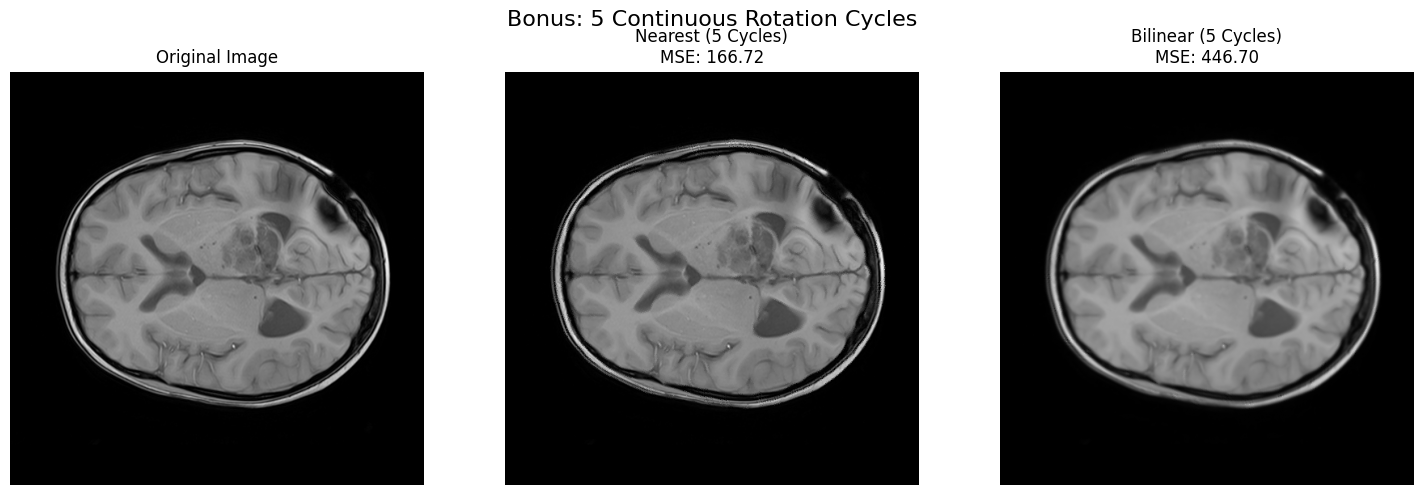

In [2]:
# ==========================================
# Bonus: 5次连续旋转循环信息损失对比
# ==========================================
img_bonus_nn = img.copy()
img_bonus_bi = img.copy()

print("正在计算 5 次连续旋转循环，请稍候...")
for i in range(5):
    img_bonus_nn = matrix_rotate(img_bonus_nn, theta, method='nearest')
    img_bonus_nn = matrix_rotate(img_bonus_nn, -theta, method='nearest')
    
    img_bonus_bi = matrix_rotate(img_bonus_bi, theta, method='bilinear')
    img_bonus_bi = matrix_rotate(img_bonus_bi, -theta, method='bilinear')

mse_nn_5 = calculate_mse(img, img_bonus_nn)
mse_bi_5 = calculate_mse(img, img_bonus_bi)

print("-" * 40)
print(f"信息损失对比 (1次 vs 5次循环):")
print(f"最近邻 (Nearest): 1次 MSE = {mse_nn:.4f}  |  5次 MSE = {mse_nn_5:.4f}")
print(f"双线性 (Bilinear): 1次 MSE = {mse_bi:.4f}  |  5次 MSE = {mse_bi_5:.4f}")
print("-" * 40)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Bonus: 5 Continuous Rotation Cycles', fontsize=16)

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original Image")

axes[1].imshow(img_bonus_nn, cmap='gray')
axes[1].set_title(f"Nearest (5 Cycles)\nMSE: {mse_nn_5:.2f}")

axes[2].imshow(img_bonus_bi, cmap='gray')
axes[2].set_title(f"Bilinear (5 Cycles)\nMSE: {mse_bi_5:.2f}")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 实验结果与分析

在数字图像矩阵中，除 $90^\circ$ 整数倍的旋转外，任何角度的旋转都需要对像素网格重新计算坐标并进行重采样（插值）。由于小数坐标的存在，插值本质上是对真实像素位置的近似，这是一个不可逆的有损过程。1次旋转循环（$\theta \to -\theta$）只会经历两次重采样带来的误差。而5次连续旋转循环会经历十次重采样。随着插值次数的增加，重采样误差会不断累积。

最近邻插值5次循环后的 MSE 与 1次循环后的 MSE 几乎持平（变化极小）。这是因为最近邻插值本质上是离散的坐标取整。在第1次正反旋转循环中，因为网格不对齐导致的子像素信息丢失（重采样误差）已经一次性发生，图像形成了一种伴随锯齿的稳定。在后续的重复循环中，由于变换矩阵和四舍五入逻辑固定，像素只是在固定的离散网格间来回搬运，不再产生新的严重舍入冲突，因此误差不再显著累积。

双线性插值与最近邻插值不同，双线性插值每次映射都会计算周围像素的加权平均值。这意味着每次正向或反向旋转，都会对图像进行一次低通滤波平滑。5次连续循环相当于对图像反复执行了10次平滑操作，导致图像高频信息（边缘、细节）持续且不可逆地流失。因此，其 MSE 会随着循环次数的增加而显著上升，视觉上也会变得越来越模糊。

结论：如果需要保持图像的锐度且能容忍锯齿，最近邻插值在极端的反复几何变换中具有一定的稳定性；而双线性插值虽然单次视觉效果平滑，但在多次串联变换中会导致严重的误差累积和细节模糊。

# Project2 Intensity Transform



## 实验要求

基本任务：使用提供的lab2_CT.npy数据，设计并实现以下实验。
- 设计变换方法：设计并实现对数变换 (Log transform) 和幂律变换 (Power transform)。
- 视觉效果优化：调整变换的参数，以获得图像的最佳视觉效果。
- 差异与参数分析：解释不同变换方法和所选参数之间的主要差异。
- 最佳参数选择机制：解释在处理图像时如何选择最佳参数。
- 特定临床目标的参数应用：针对临床上观察肺部组织 (lung tissue) 和骨骼结构 (bone structures) 的不同需求，分别设计或选择最合适的变换参数。
- 技术要求：必须使用矩阵运算实现。


## 实验原理



空间域的强度变换（Intensity Transform）是图像增强的基础方法之一，它直接对图像矩阵中的每个像素灰度值进行映射操作。其基本数学形式为 $s = T(r)$，其中 $r$ 为原图像像素的灰度值，$s$ 为变换后的新灰度值，而 $T$ 就是我们定义的强度变换函数。

本实验重点探讨两种非线性映射方法：
* **对数变换 (Log Transform)**：其公式定义为 $s = c \cdot \log(1 + r)$。由于对数函数的导数特性——在自变量较小（低灰度区）时斜率非常大，而在自变量较大（高灰度区）时斜率平缓，因此该变换能够极为显著地拉伸图像的暗部细节，同时强力压缩亮部的动态范围。为了探究参数影响，我们在对数项内部引入尺度控制参数 $v$（常用于广义对数变换），公式拓展为：$$s = c \cdot \log(1 + v \cdot r)$$其中 $c = \frac{1}{\log(1 + v \cdot \max(r))}$ 用于将灰度值重新归一化到 $[0, 1]$ 区间。参数 $v$ 控制了对数曲线的弯曲程度和初始斜率。
* **幂律变换/伽马变换 (Power Transform)**：其公式定义为 $s = c \cdot r^\gamma$。幂律变换是一种更加普适且灵活的灰度映射工具，其映射曲线的凹凸性完全由指数参数 $\gamma$ 控制。通过改变 $\gamma$ 值，既可以得到类似对数变换的效果（拉伸暗部），也可以反其道而行之（拉伸亮部）。


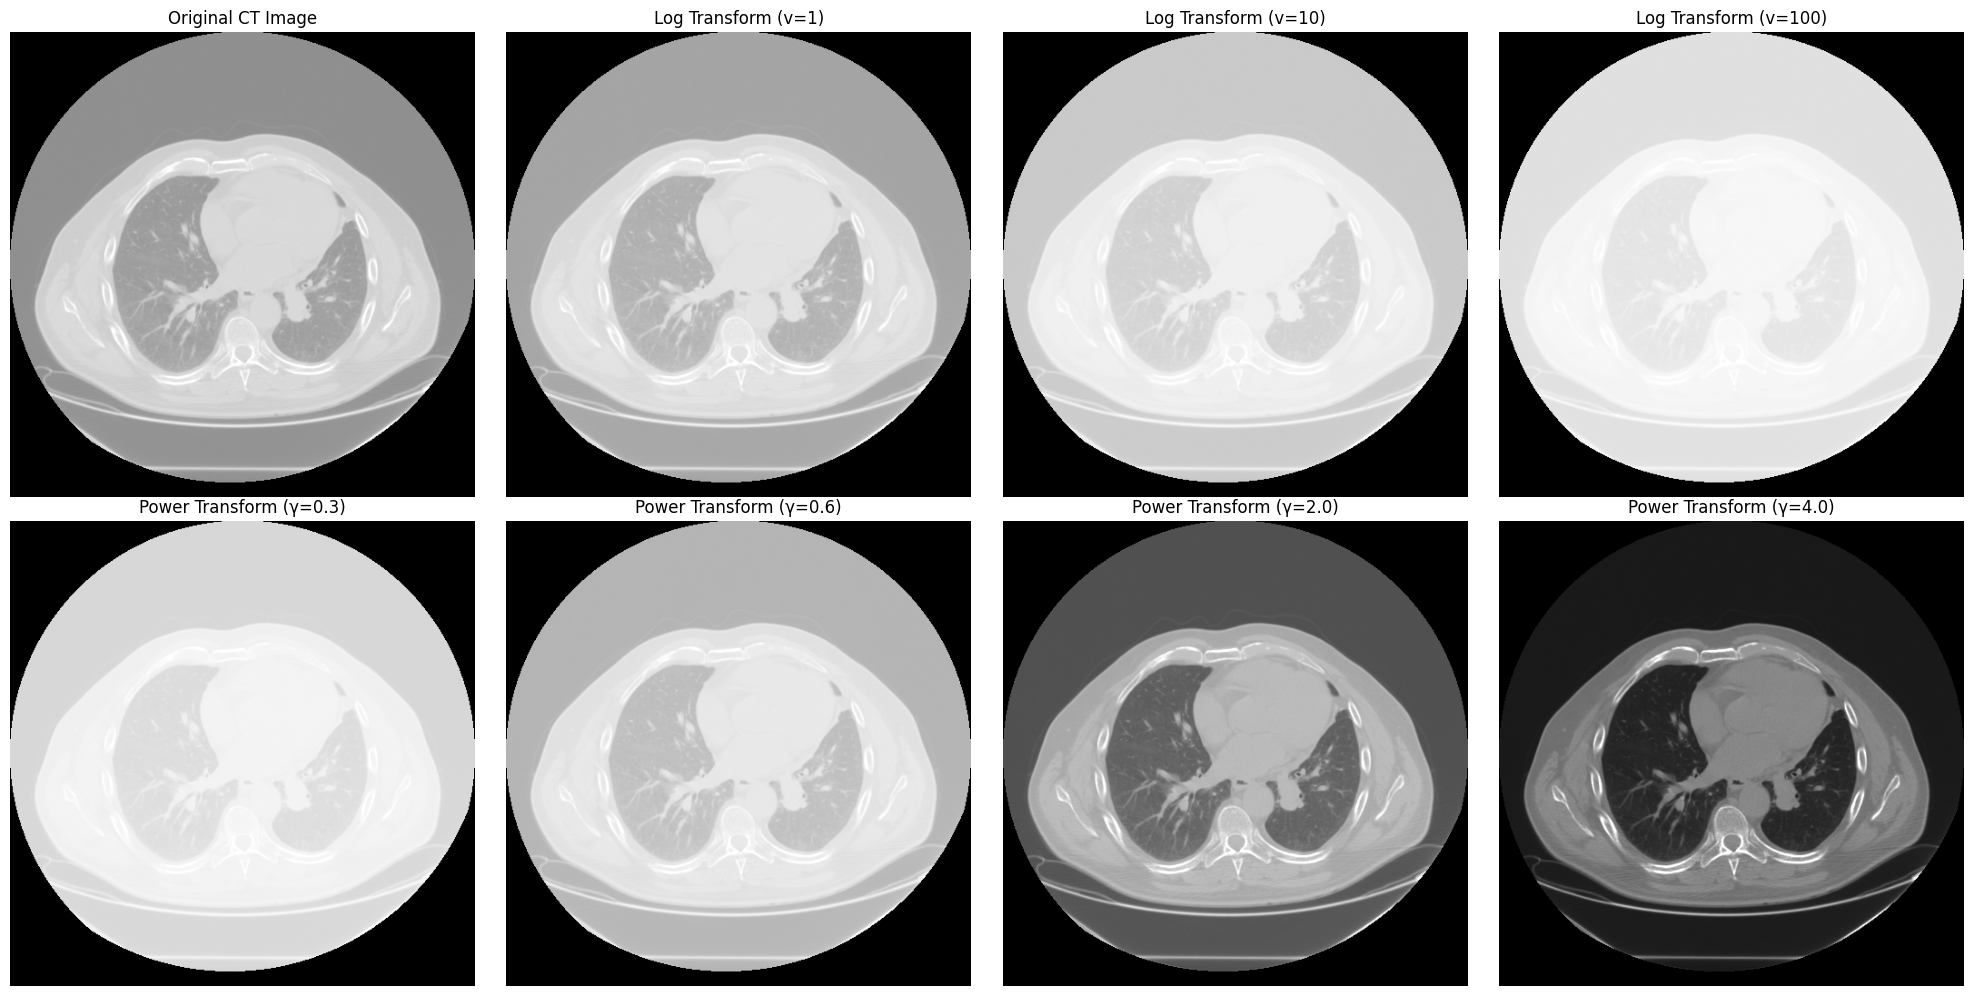

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 读取并归一化原始 CT 图像到 [0, 1] 区间
# 注意：文件路径已更新为 lab2_data 文件夹下
img_ct = np.load('lab2_data/lab2_CT.npy')
img_ct_norm = (img_ct - np.min(img_ct)) / (np.max(img_ct) - np.min(img_ct))

# 1. 探究对数变换参数 v 的影响
v_values = [1, 10, 100]  # v 越大，对数曲线在低灰度区的拉伸越剧烈
log_imgs = []
for v in v_values:
    # 计算归一化系数 c
    c_log = 1 / np.log(1 + v * np.max(img_ct_norm))
    # 矩阵运算实现参数化对数变换
    img_log = c_log * np.log(1 + v * img_ct_norm)
    log_imgs.append(img_log)

# 2. 探究幂律变换参数 gamma 的影响
gammas = [0.3, 0.6, 2.0, 4.0]
power_imgs = []
for gamma in gammas:
    c_power = 1 / np.power(np.max(img_ct_norm), gamma)
    img_power = c_power * np.power(img_ct_norm, gamma)
    power_imgs.append(img_power)

# 绘图展示所有参数对比
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# 第一行：原图与对数变换参数对比
axes[0, 0].imshow(img_ct_norm, cmap='gray')
axes[0, 0].set_title("Original CT Image")
axes[0, 1].imshow(log_imgs[0], cmap='gray')
axes[0, 1].set_title(f"Log Transform (v={v_values[0]})")
axes[0, 2].imshow(log_imgs[1], cmap='gray')
axes[0, 2].set_title(f"Log Transform (v={v_values[1]})")
axes[0, 3].imshow(log_imgs[2], cmap='gray')
axes[0, 3].set_title(f"Log Transform (v={v_values[2]})")

# 第二行：幂律变换参数对比
axes[1, 0].imshow(power_imgs[0], cmap='gray')
axes[1, 0].set_title(f"Power Transform (γ={gammas[0]})")
axes[1, 1].imshow(power_imgs[1], cmap='gray')
axes[1, 1].set_title(f"Power Transform (γ={gammas[1]})")
axes[1, 2].imshow(power_imgs[2], cmap='gray')
axes[1, 2].set_title(f"Power Transform (γ={gammas[2]})")
axes[1, 3].imshow(power_imgs[3], cmap='gray')
axes[1, 3].set_title(f"Power Transform (γ={gammas[3]})")

for ax in axes.flatten():
    ax.axis('off')
plt.tight_layout()
plt.show()

### 实验结果与分析

结合上述代码的运行结果图，我们对方法与参数的差异进行深度剖析。

#### 对数变换法和幂律变换方法的差异
* 从对数函数的导数 $\frac{d}{dr}(\log(1+r)) = \frac{1}{1+r}$。可以看出，随着输入灰度 $r$ 的增加，变化率单调递减。这意味着对数变换只能用于扩展低灰度（暗部）细节，并强制压缩高灰度（亮部）细节。它无法被反向配置为增强亮部。
* 幂律函数的导数为 $\gamma \cdot r^{\gamma-1}$。通过调节 $\gamma$ 与 $1$ 的相对大小，导数可以呈现单调递增（扩展亮部）或单调递减（扩展暗部）。因此，幂律变换在医学图像处理中覆盖的场景远广于对数变换。

#### 对数变换参数 ($v$) 的影响
在公式 $s = c \cdot \log(1 + v \cdot r)$ 中，参数 $v$ 决定了映射曲线进入平缓饱和区的速度：
* 当 $v$ 较小（如 $v=1$）时，曲线的弯曲程度较温和，低灰度区的拉伸比例和高灰度区的压缩比例都处于适中水平，图像整体变亮，暗部细节有一定浮现。
* 当 $v$ 显著增大（如 $v=10, 100$） 时，公式在 $r$ 极小的时候就能产生极大的输出跨度。这意味着算法对极暗像素比较敏感。在图像上的直观表现是，原本漆黑一片的背景中极其微弱的噪声或组织残影被极其猛烈地提亮；但代价是由于动态范围被过度分配给了极暗区，中等亮度和高亮度的软组织、骨骼全部被压缩到了高光区间，导致图像发生严重的过曝（Wash-out），丧失了大部分原本清晰的解剖学结构。

#### 幂律变换参数 ($\gamma$) 的影响
* 增强暗部 ($\gamma < 1$)：效果在宏观上类似于对数变换，曲线呈上凸形态。$\gamma$ 越小（如 $0.3$），对极低灰度的拉伸越明显。与高参数的对数变换相比，低 $\gamma$ 值的幂律变换在整体亮度提升的同时，往往能保留比极端对数变换稍多一些的中灰度细节过度。
* 增强亮部 ($\gamma > 1$)：曲线呈下凹形态。此时机制完全反转，原图中原本偏暗的像素（如软组织、空气、背景）被指数级压暗，近乎为零；而原图中高灰度像素（如致密骨骼）的内部灰阶差异被指数级放大。$\gamma$ 值越大，这种“抑制暗部、剥离亮部”的阈值效应就越强，图像对比度变得极其锐利。
方法差异：对数变换只能单方向地“提亮暗部”；而幂律变换更为灵活，可以通过调节 $\gamma$ 实现双向控制（$\gamma<1$ 提亮暗部，$\gamma>1$ 压暗背景拉伸亮部）。

### 最佳参数选择
直接从肉眼观察上述运行结果，我个人认为幂律变换（当 $\gamma = 2.0$ 时）取得了最干净、对比度最强烈的视觉效果。

原始 CT 图像整体偏暗，且背景中包含了大量模糊的低灰度软组织底噪。如果使用对数变换或低参数的幂律变换，反而会将这些底噪无限放大。而当 $\gamma = 2.0$ 时，下凹的指数曲线恰好完美压制了这层低灰度底噪，将背景过滤得极其干净；同时，它将处于中高灰度区间的核心解剖结构（如头骨轮廓）的对比度大幅拉开，使得图像在主观视觉上最锐利、最清晰。

### 特定临床目标的参数定向选择

虽然从直观视觉上 $\gamma = 2.0$ 最好，但在真正的医学临床诊断中，并不存在绝对的最佳参数，因为不同的生理组织密度截然不同，需要根据观察目标进行极端的参数定向选择。


#### 肺部组织

肺泡内充满气体，X 射线穿透率极高，在 CT 图像上呈现为大面积的极低灰度区（黑色暗区）。

参数选择：为了寻找隐藏在暗区中的微小血管或结节，必须放大低灰度区间的像素差异。因此，应当选择高 $v$ 值的对数变换（如 $v=50$）。这能增加暗部的细节，虽然代价是使得外围骨骼严重过曝，但对于肺部的定向诊断是必要的手段。

#### 骨骼结构

骨骼富含高密度钙质，在 CT 图像上呈现为极高灰度区（白亮区）。

参数选择：为了观察骨小梁网状结构或细微的骨皮质裂纹，要求区分极亮区域内部的微小灰阶差异。对数变换在此处完全失效。必须选择高 $\gamma$ 值的幂律变换（如 $\gamma=3.0$）。该参数能将软组织强行压黑作为纯净背景，并利用指数陡增的尾部曲线，将高光区域的微小差异高对比度地锐化出来。

从以下代码运行结果可以看到，$v=50$的对数变换和$\gamma=3$的幂律变换对于观察肺部CT和骨骼CT的效果良好，但在临床实际中，选择什么样的变换、如何选择参数还应根据实际来判断。

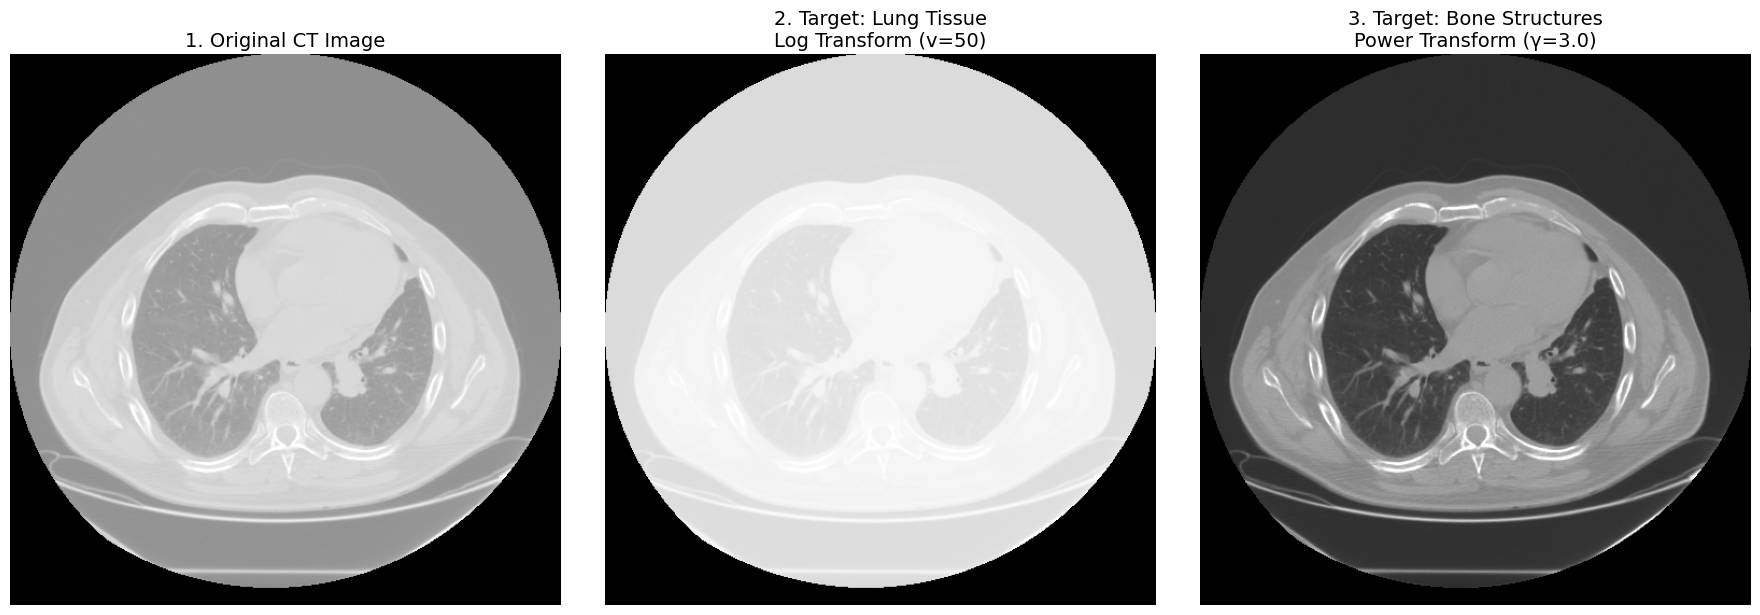

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 核心变换函数设计 (使用矩阵运算)
# ==========================================
def log_transform_v(img, v=1.0):
    """
    参数化对数变换: s = c * log(1 + v * r)
    参数 v 越大，对数曲线曲率越高，对暗部的拉伸越剧烈。
    """
    img_norm = (img - img.min()) / (img.max() - img.min())
    c = 1.0 / np.log1p(v) 
    img_log = c * np.log1p(v * img_norm)
    return np.clip(img_log, 0, 1)

def power_transform(img, gamma=1.0):
    """
    幂律(Gamma)变换: s = r^gamma
    """
    img_norm = (img - img.min()) / (img.max() - img.min())
    img_power = np.power(img_norm, gamma)
    return np.clip(img_power, 0, 1)

# ==========================================
# 2. 数据加载
# ==========================================
# 确保你的 lab2_CT.npy 文件存放在当前目录的 lab2_data 文件夹下
file_path = os.path.join('lab2_data', 'lab2_CT.npy')
img_ct = np.load(file_path)

# ==========================================
# 3. 特定组织的定向增强执行代码
# ==========================================

# 目标 A：肺部组织 (暗区拉伸) -> 使用高曲率对数变换
# v=50 能极大提升极暗区域的亮度，暴露出肺部微小纹理
img_lung_enhanced = log_transform_v(img_ct, v=50) 

# 目标 B：骨骼结构 (亮区拉伸) -> 使用高 Gamma 幂律变换
# gamma=3.0 的下凹曲线能压暗软组织背景，锐化高光骨骼区域的对比度
img_bone_enhanced = power_transform(img_ct, gamma=3.0) 

# ==========================================
# 4. 可视化结果展示
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_ct, cmap='gray')
axes[0].set_title('1. Original CT Image', fontsize=14)

axes[1].imshow(img_lung_enhanced, cmap='gray')
axes[1].set_title('2. Target: Lung Tissue\nLog Transform (v=50)', fontsize=14)

axes[2].imshow(img_bone_enhanced, cmap='gray')
axes[2].set_title('3. Target: Bone Structures\nPower Transform (γ=3.0)', fontsize=14)

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

# Project 3——Spatial Filter: High pass filter

## 实验内容
使用提供的 X-Ray 影像数据 lab2_filter.npy，设计并编写代码实现图像的空间域增强。

- 必须包含的步骤：使用 8 邻域拉普拉斯滤波器 (8-neighbor Laplacian filter) 和 两个方向的 3x3 Sobel 滤波器。
- 自主设计步骤：在上述基础上增加更多处理步骤以形成完整的增强管线 (Pipeline)。
- 详细解释整个增强管线是如何设计的，以及每一个步骤的具体作用和效果。

## 实验原理


空间滤波的本质：在图像处理中，滤波器通常是一个 3x3 的数学权重矩阵（核）。滤波操作即将该核在原始图像矩阵上进行空间滑动，通过“对应元素相乘并求和（卷积运算）”来计算中心点的新像素值。

本实验选用的两个核心算子矩阵参数均由严格的数学微分推导而来。

### 8 邻域拉普拉斯算子 (8-neighbor Laplacian)

- 算子矩阵：

$$\begin{bmatrix}
-1 & -1 & -1 \\
-1 &  8 & -1 \\
-1 & -1 & -1
\end{bmatrix}$$

- 作用原理：拉普拉斯算子是一种二阶微分算子。其矩阵元素总和为 0，意味着它在灰度均匀的平坦区域响应为 0。但一旦遇到像素值的突变，无论这种突变是真实的组织边缘，还是极其微小的随机噪声，它都会产生强烈的响应。

- 特性：对图像中的任何微小变化（细节和高频噪声）极其敏感。

### 3x3 Sobel 算子

- 算子矩阵：分为水平 ($x$) 和垂直 ($y$) 两个方向的偏导数：

$$Sobel_x = \begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}, \quad
Sobel_y = \begin{bmatrix}
-1 & -2 & -1 \\
0 &  0 &  0 \\
1 &  2 &  1
\end{bmatrix}$$

- 作用原理：Sobel 是一种一阶微分算子。以 $Sobel_x$ 为例，它计算左右像素的差值，中间行权重加倍（如 2 和 -2）是为了在求导的同时提供一定的平滑滤波效果。

- 特性：反应相对迟钝，只对明显、粗壮的真实图像结构边缘有强烈响应，而有效忽略了细微的背景高频噪声。

## 设计思路

医学 X-Ray 图像由于人体组织的散射及设备限制，往往对比度低且伴随随机噪声。为了清晰观察骨骼微细结构，常规思路是应用高通滤波器（如前文的拉普拉斯算子）锐化图像。

然而，二阶算子的噪声敏感性会引发一个矛盾。若直接将拉普拉斯锐化结果叠加至原图，隐匿的高频底噪会被急剧放大，导致整个画面被雪花噪声淹没，严重干扰临床诊断。

为了打破锐化边缘必将放大噪声的困境，本实验参考经典的图像增强流程，设计了一条双分支复合管线。核心设计思想是利用一阶微分（Sobel）去约束和过滤二阶微分（Laplacian）。

- 获取初级锐化结果（含噪）：应用拉普拉斯算子提取高频细节，并直接叠加到原图上，得到一幅边缘锐利但伴随大量背景噪声的初级锐化图像。

- 提取平滑掩膜（纯净）：利用抗噪性强的 Sobel 算子单独提取粗壮的骨骼主边缘，并使用 5x5 均值滤波平滑处理，制成一张从 0 到 1 渐变的权重掩膜 (Mask)。

- 屏蔽与最终融合：将初级锐化结果（含噪）与掩膜相乘。在平坦区，掩膜系数趋于 0，噪声被压制；在边缘区，锐化细节被保留。最后，将过滤后的结果再次加回原图以确保背景的基础信息完整，并使用 Gamma 变换提亮、拉伸整体动态范围。

### 算法设计流程图

<div style="margin: 0 auto; max-width: 800px; font-family: 'Times New Roman', Times, serif;">
<table style="width:100%; text-align:center; border-collapse: collapse; border: 1px solid #000000; color: #000000;">
<tr>
<th colspan="3" style="padding: 12px; border: 1px solid #000000; background-color: #F5F5F5; font-size: 16px;">
1. Original Image (原始图像)
</th>
</tr>
<tr>
<td style="width:45%; padding: 15px; border-right: 1px dashed #000000; vertical-align: top;">
<strong>【分支 A：初级锐化（含噪）】</strong>


&darr; 8-邻域 Laplacian 滤波 &darr;


<strong>2. Laplacian (High Freq Details)</strong>



<span style="font-size: 13px; color: #333333;">(提取高频变化，包含噪声)</span>

&darr; 加回原图 (img + laplacian_img) &darr;



<strong>3. Simple Sharpening (Noisy)</strong>


<span style="font-size: 13px; color: #333333;">(边缘清晰但伴随大量颗粒噪声)</span>
</td>
<td style="width:10%; border-bottom: 1px solid #000000;"></td>
<td style="width:45%; padding: 15px; border-left: 1px dashed #000000; vertical-align: top;">
<strong>【分支 B：平滑掩膜制作】</strong>



&darr; 3x3 Sobel 滤波 (X与Y方向) &darr;



<strong>4. Sobel Magnitude (Edges)</strong>

<span style="font-size: 13px; color: #333333;">(仅提取主要结构边缘，忽略细节噪声)</span>


&darr; 5x5 均值平滑 (Box Filter) &darr;


<strong>5. Smoothed Sobel (Mask)</strong>


<span style="font-size: 13px; color: #333333;">(生成带灰阶过渡的平滑权重掩膜)</span>
</td>
</tr>
<tr>
<td colspan="3" style="padding: 15px; border: 1px solid #000000;">
&darr; 将【步骤 3】与【步骤 5】结果逐像素相乘 (Masking Multiplication) &darr;


<strong>6. Masked Laplacian</strong>


<span style="font-size: 13px; color: #333333;">(在骨骼处保留拉普拉斯锐化细节，在平坦背景处用掩膜系数压制噪声)</span>
</td>
</tr>
<tr>
<td colspan="3" style="padding: 15px; border: 1px solid #000000;">
&darr; 将掩膜相乘结果加回【步骤 1】的原始图像 &darr;


<strong>7. Mask Added to Original</strong>


<span style="font-size: 13px; color: #333333;">(实现无噪背景下的干净锐化融合)</span>
</td>
</tr>
<tr>
<td colspan="3" style="padding: 15px; border: 1px solid #000000; background-color: #F5F5F5;">
&darr; 应用 Gamma 变换 (&gamma; = 0.5) 拉伸对比度 &darr;


<strong>8. Final: Gamma Transformed</strong>


<span style="font-size: 13px; color: #333333;">(最终增强的临床展示图)</span>
</td>
</tr>
</table>
</div>

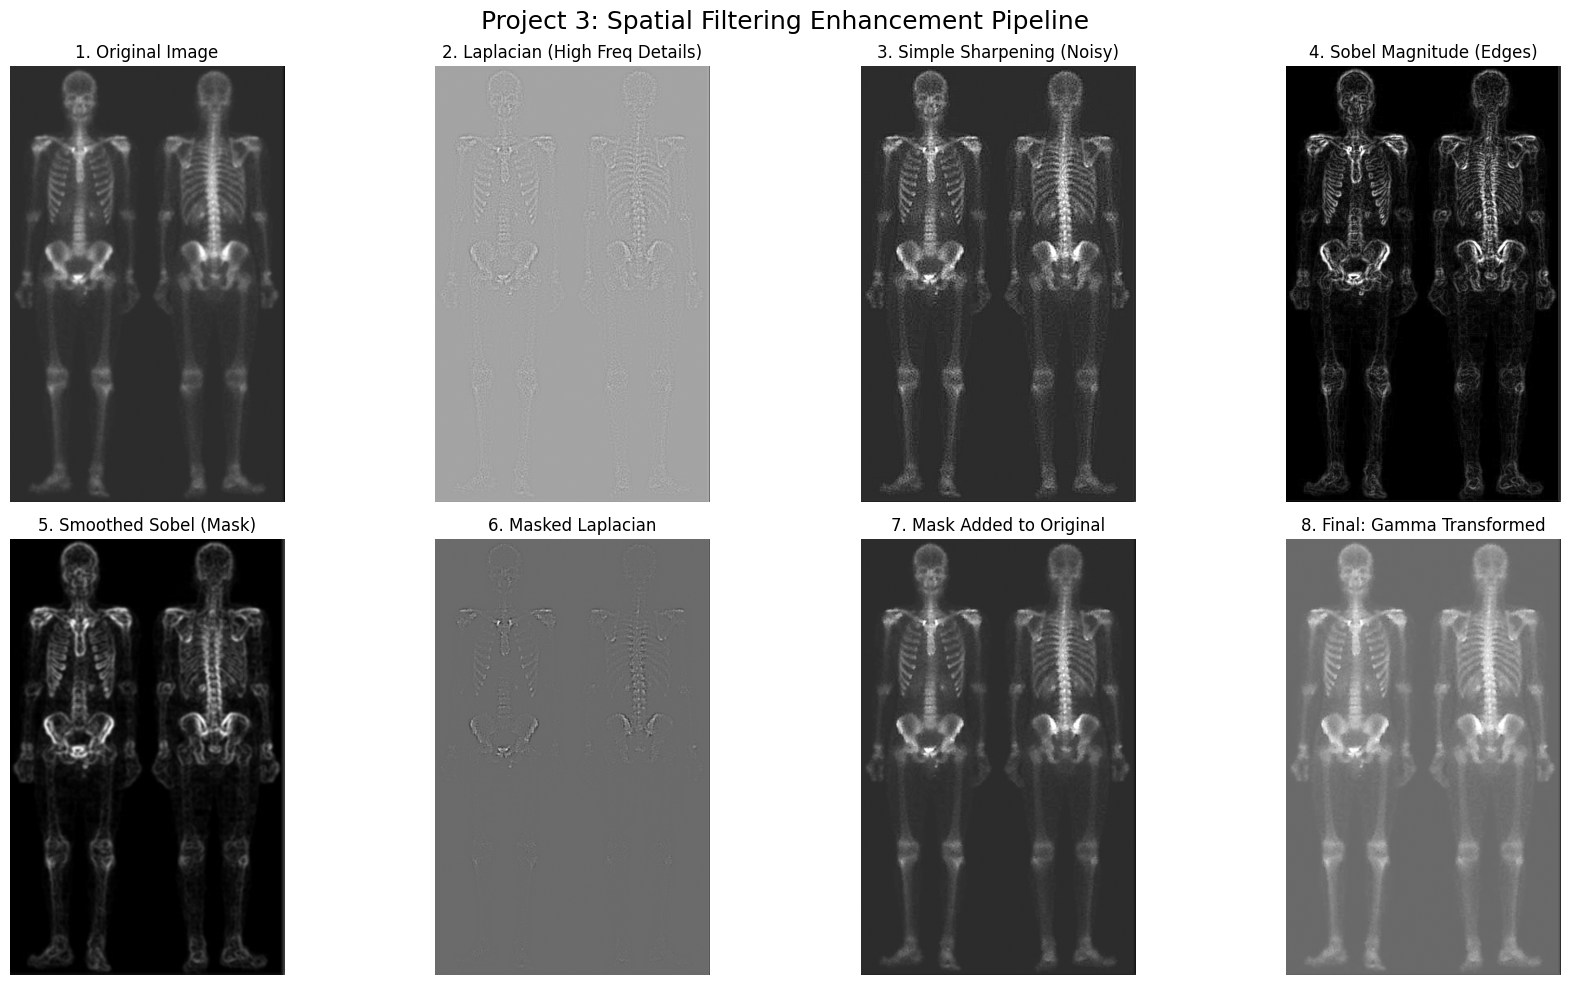

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 加载数据与预处理
# ==========================================
file_path = os.path.join('lab2_data', 'lab2_filter.npy')
img = np.load(file_path)

if img.ndim == 3:
    img = img[:, :, 0]
img = (img - img.min()) / (img.max() - img.min())

# ==========================================
# 2. 算子定义
# ==========================================
laplacian_kernel = np.array([[-1, -1, -1],
                             [-1,  8, -1],
                             [-1, -1, -1]])

sobel_x_kernel = np.array([[-1,  0,  1],
                           [-2,  0,  2],
                           [-1,  0,  1]])
sobel_y_kernel = np.array([[-1, -2, -1],
                           [ 0,  0,  0],
                           [ 1,  2,  1]])

# ==========================================
# 3. 核心滤波与增强管线 (修复后的经典管线)
# ==========================================
# [Step A] Laplacian (提取细节，包含正负值和噪声)
laplacian_img = cv2.filter2D(img, -1, laplacian_kernel)

# [Step B] Simple Sharpening (初级锐化，仅做反面教材展示)
sharpened_img = np.clip(img + laplacian_img, 0, 1)

# [Step C] Sobel (提取真实边缘)
sobel_x = cv2.filter2D(img, -1, sobel_x_kernel)
sobel_y = cv2.filter2D(img, -1, sobel_y_kernel)
sobel_mag = np.clip(np.abs(sobel_x) + np.abs(sobel_y), 0, 1)

# [Step D] Smoothed Sobel (平滑掩膜)
box_kernel = np.ones((5, 5)) / 25
sobel_smoothed = cv2.filter2D(sobel_mag, -1, box_kernel)

# [Step E] 掩膜相乘 (应该用纯细节去乘掩膜，过滤掉背景细节噪声)
masked_laplacian = laplacian_img * sobel_smoothed

# [Step F] 最终融合 (将过滤后的干净细节加回原图)
enhanced_img = np.clip(img + masked_laplacian, 0, 1)

# [Step G] Gamma 对比度增强
gamma = 0.5
final_result = np.power(enhanced_img, gamma)

# ==========================================
# 4. 可视化分析展示
# ==========================================
def norm_for_display(image):
    # 将含有负数的矩阵居中归一化，0会变成0.5(灰色)
    return (image - image.min()) / (image.max() - image.min() + 1e-8)

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Project 3: Spatial Filtering Enhancement Pipeline', fontsize=18)

axes[0, 0].imshow(img, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title("1. Original Image")

axes[0, 1].imshow(norm_for_display(laplacian_img), cmap='gray')
axes[0, 1].set_title("2. Laplacian (High Freq Details)")

axes[0, 2].imshow(sharpened_img, cmap='gray', vmin=0, vmax=1)
axes[0, 2].set_title("3. Simple Sharpening (Noisy)")

axes[0, 3].imshow(norm_for_display(sobel_mag), cmap='gray')
axes[0, 3].set_title("4. Sobel Magnitude (Edges)")

axes[1, 0].imshow(norm_for_display(sobel_smoothed), cmap='gray')
axes[1, 0].set_title("5. Smoothed Sobel (Mask)")

# 过滤后的纯净细节
axes[1, 1].imshow(norm_for_display(masked_laplacian), cmap='gray')
axes[1, 1].set_title("6. Masked Laplacian")

axes[1, 2].imshow(enhanced_img, cmap='gray', vmin=0, vmax=1)
axes[1, 2].set_title("7. Mask Added to Original")

axes[1, 3].imshow(final_result, cmap='gray', vmin=0, vmax=1)
axes[1, 3].set_title("8. Final: Gamma Transformed")

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()

## 实验结果与分析

### 图 1. Original Image（原始图像）

基础底图，整体偏暗，由于散射效应，骨小梁结构对比度较低。

### 图 2. Laplacian (High Freq Details)

二阶微分算子极度发散，抓取了骨骼纹理的同时，敏锐地提取了背景中的高频随机噪声（表现为密密麻麻的白色噪点）。

### 图 3. Simple Sharpening (Noisy)

由图1 + 图2生成。画面虽然看似锐利，但出现了强烈颗粒感，即雪花噪声，丧失了临床读片价值，证明不能直接使用拉普拉斯算子滤波。

### 图 4. Sobel Magnitude (Edges)

一阶微分算子反应迟钝，因此成功避开了高频噪声，仅提取了对比强烈的骨骼主要外轮廓，背景干净。

### 图 5. Smoothed Sobel (Mask)

利用 5x5 均值滤波对图4进行平滑。真实的边缘原本过于锐利，平滑处理使其转变为带有灰阶宽度的渐变光晕，使得后续作为权重乘数时，边界过渡更为自然柔和。

### 图 6. Masked Laplacian

操作：masked_laplacian = laplacian_img * sobel_smoothed（图2 × 图5）。

在无边缘的平坦区，掩膜系数趋近 0，图2中的拉普拉斯背景噪声大幅降低；在骨骼边缘区，掩膜的放行使得拉普拉斯的微细锐利边缘得以完美保留。

### 图 7. Mask Added to Original

操作：enhanced_img = img + masked_laplacian（图1基础底图 + 图6纯净细节）。

将提取出的无噪细节加回原图。与图3的表现形成对比，图7在大幅提升骨骼锐度和清晰度的同时，完美维持了软组织背景的纯净与平滑。

### 图 8. Final: Gamma Transformed

操作：final_result = np.power(enhanced_img, 0.5)。

应用 $\gamma = 0.5$ 的幂律变换。对融合后依然偏暗的图像进行适度提亮，彻底展开图像的动态范围，使得骨骼内部的微观纹理层次分明，输出具备最高临床诊断价值的增强医学影像。

## 实验心得

通过本次《生物医学图像处理》的综合实验，我不仅在代码工程层面熟练掌握了 Numpy 的矩阵运算，更在算法的底层逻辑、数学工具的临床应用上获得了极其深刻的启发。

### 重采样的不可逆

在 Project 1 的空间变换中，在数字图像的离散矩阵世界里，即使是理论上完全可逆的几何变换（先旋转 $\theta$ 再旋转 $-\theta$），也会因为重采样和插值算法的介入而导致永久性的信息流失。
通过对比实验我发现。最近邻插值（Nearest Neighbor）虽然会在单次变换中产生严重的锯齿边缘，但由于其本质只是离散网格坐标的四舍五入搬运，在多次反复循环时，反而展现出一种特殊的稳定态，误差不再显著累积；而双线性插值（Bilinear）虽然单次视觉观感平滑，但其加权平均的本质相当于一次低通滤波。在 5 次连续的旋转循环后，图像如同被过度平滑，高频边缘信息大量丢失，MSE 呈现爆发式增长。这警示我在未来处理医学影像时，必须将非必要的空间重采样步骤降至最低，以保护原始病理信息。

### 理解临床导向的参数设计

在 Project 2 的强度变换（Intensity Transform）中，我原本陷入了寻找一个能让全图所有组织都好看的完美全局参数的误区（直接让大模型给我推荐合适的参数）。但通过对对数变换和幂律变换的数学导数特性进行深入剖析，我明白了医学图像处理的参数选择不存在通解，算法必须为特定的临床诊断目标妥协与服务。

当我们需要寻找暗区（如充满气体的肺部组织）中微弱的血管网络时，必须利用高曲率的对数变换（如 $v=50$）或低  $\gamma$ 值的幂律变换，以舍弃高亮骨骼细节为代价，增强低灰度区的对比度。

当我们需要观察亮区（如致密骨骼）中的微小裂缝时，对数变换由于其导数递减的特性会完全失效。此时必须切换至高 $\gamma$ 值（如 $\gamma=3.0$）的幂律变换，利用其将软组织压暗为纯净背景。

### 领略增强图像中设计的智慧

Project 3 的实验让我意识到，单一的数学算子往往带有致命的缺陷。例如二阶拉普拉斯算子虽然能敏锐抓取微细纹理，但会将医学底噪同步放大，直接使用会导致画面被“雪花噪声”淹没。

然而，通过引入经典的增强流程，我在大模型指导下利用了一阶微分（Sobel）算子的迟钝与抗噪性。将平滑后的 Sobel 边缘提取结果作为权重掩膜（Mask），去约束和过滤二阶微分（Laplacian）算子的敏感与发散性。在平坦背景处归零噪声，在真实骨骼边缘处放行细节。这种利用不同数学工具优势互补、化解矛盾的设计哲学，对于我未来在生物医学工程领域开发复杂的软件分析系统具有极其重要的指导意义。